In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
depth_2011 = pd.read_csv('./bc2011.lib001_rotated.minimap2_lowNscore_aligned.depth', sep='\t').rename(columns={'/tmp/slurm_tmp/518378/aligned.sorted.bam': 'depth'})
# display(depth_2011)
depth_2015 = pd.read_csv('./bc2015.lib001_rotated.minimap2_lowNscore_aligned.depth', sep='\t').rename(columns={'/tmp/slurm_tmp/518379/aligned.sorted.bam': 'depth'})
# display(depth_2015)

depth_merged = pd.merge(depth_2011.drop(columns=['#CHROM']), depth_2015.drop(columns=['#CHROM']), on='POS', how='outer',suffixes=('_2011', '_2015'))

total_reads_2011 = 6429309
total_reads_2015 = 5666574
depth_merged['coverage_percent_2011'] = depth_merged['depth_2011']/total_reads_2011*100
depth_merged['coverage_percent_2015'] = depth_merged['depth_2015']/total_reads_2015*100

# Pivot/melt the 4 columns into long format with columns: barcode, depth, coverage_percent

depth_melted = pd.melt(
    depth_merged,
    id_vars=['POS'],
    value_vars=['depth_2011', 'depth_2015', 'coverage_percent_2011', 'coverage_percent_2015'],
    var_name='type',
    value_name='value'
)

# Assign barcode and what the value represents based on 'type'
def parse_type(t):
    if '2011' in t:
        barcode = '2011'
    elif '2015' in t:
        barcode = '2015'
    else:
        barcode = None
    if t.startswith('depth'):
        col = 'depth'
    else:
        col = 'coverage_percent'
    return pd.Series({'barcode': barcode, 'col': col})

parsed = depth_melted['type'].apply(parse_type)
depth_melted['barcode'] = parsed['barcode']
depth_melted['col'] = parsed['col']

depth_long = depth_melted.pivot_table(
    index=['POS', 'barcode'],
    columns='col',
    values='value'
).reset_index()



depth_long

col,POS,barcode,coverage_percent,depth
0,1,2011,90.644111,5827790.0
1,1,2015,88.314438,5004403.0
2,2,2011,91.026345,5852365.0
3,2,2015,88.717204,5027226.0
4,3,2011,91.089353,5856416.0
...,...,...,...,...
8765,4383,2015,91.804695,5202181.0
8766,4384,2011,94.181583,6055225.0
8767,4384,2015,91.729359,5197912.0
8768,4385,2011,93.645289,6020745.0


/tmp/ipykernel_546528/938230673.py:2: DtypeWarning: Columns (0: CMV_enhancer, 1: CMV_enhancer_rev, 2: EX1, 3: EX1_rev, 4: IN1, 5: IN1_rev, 6: EX2_3ss, 7: EX2_3ss_rev, 8: EX2_SMN2_5ss, 9: EX2_SMN2_5ss_rev, 10: EX2_ELP1_ris_5ss, 11: EX2_ELP1_ris_5ss_rev, 12: EX3, 13: EX3_rev, 14: polyA, 15: polyA_rev, 16: ori, 17: ampR, 18: ampR_rev, 19: ampR_promoter_rev) have mixed types. Specify dtype option on import or set low_memory=False.
  regex_df = pd.read_csv(reg_path)


,CMV_enhancer,EX1,IN1,EX2_3ss,EX2_SMN2_5ss,EX2_ELP1_ris_5ss,IN2,EX3,polyA,ori,ampR,ampR_promoter
file_name,,,,,,,,,,,,
m84223_251126_143521_s2.hifi_reads.bc2011.bam,0.931064,0.828062,0.793701,0.812131,0.804780,0.000514,0.811028,0.818454,0.954167,0.959209,0.960787,0.956874
m84223_251126_143521_s2.hifi_reads.bc2015.bam,0.909006,0.830368,0.796828,0.814793,0.000804,0.811498,0.714536,0.723415,0.931237,0.936603,0.937047,0.932387
m84223_251126_143521_s2.hifi_reads.unassigned.bam,0.882938,0.812160,0.782870,0.798787,0.346358,0.433739,0.759027,0.761310,0.909260,0.917349,0.919502,0.891549


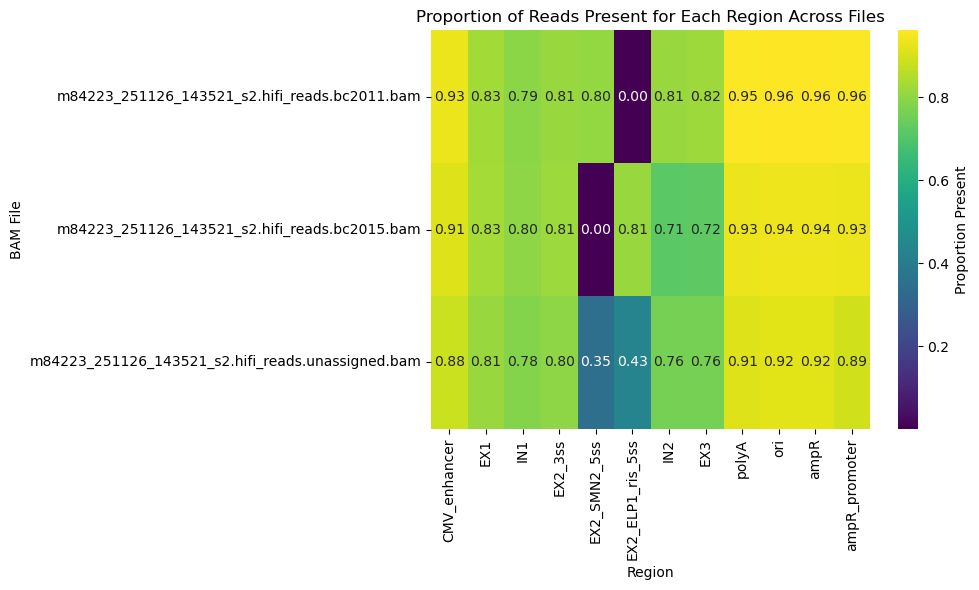

In [5]:
reg_path = '/grid/kinney/data/desmara/2025_12_03_pac_bio_library_mapping_risLlib_001_002_003_004/aligning/output/parse_regions_v2/parsed_reads_merged.csv'
regex_df = pd.read_csv(reg_path)
regions = [
    'CMV_enhancer',
    'EX1',
    'IN1', 
    'EX2_3ss', 
    'EX2_SMN2_5ss',
    'EX2_ELP1_ris_5ss',
    'IN2', 
    'EX3', 
    'polyA', 
    'ori', 
    'ampR', 
    'ampR_promoter']

match_df = regex_df[['query_name', 'file_name']].copy()

for region in regions:
    match_df[region] = regex_df[region].notna()|regex_df[region+'_rev'].notna()
match_df

match_percs = match_df.drop(columns=['query_name']).groupby('file_name').mean()
display(match_percs)

plt.figure(figsize=(10, 6))
sns.heatmap(
    match_percs,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={'label': 'Proportion Present'}
)
plt.title("Proportion of Reads Present for Each Region Across Files")
plt.xlabel("Region")
plt.ylabel("BAM File")
plt.tight_layout()
plt.show()



In [ ]:
positions_2011 = pd.Series({
    "CMV_enhancer":1367,
    "EX1":2000,
    "IN1":2090,
    "EX2_3ss":2156,
    "EX2_SMN2_5ss":2273,
    "EX2_ELP1_ris_5ss":np.nan,
    "IN2":2683,
    'EX3':3162,
    "polyA":3337,
    "ori":3799,
    "ampR":153,
    "ampR_promoter":934,
    
})
rotated_positions_2011 = positions_2011-1059
rotated_positions_2011.loc[rotated_positions_2011<0] = 4385+rotated_positions_2011.loc[rotated_positions_2011<0]
positions_2011 = rotated_positions_2011

match_reads = match_df.drop(columns=['query_name']).groupby('file_name').sum()
match_reads = match_reads.loc[['m84223_251126_143521_s2.hifi_reads.bc2011.bam']].T/total_reads_2011*100
match_reads['POS'] = positions_2011

match_reads = match_reads.reset_index().rename(columns={'index':'region','m84223_251126_143521_s2.hifi_reads.bc2011.bam':'coverage_percent'})

match_reads

file_name,region,coverage_percent,POS
0,CMV_enhancer,93.043140,308.0
1,EX1,82.749997,941.0
2,IN1,79.316160,1031.0
3,EX2_3ss,81.157975,1097.0
4,EX2_SMN2_5ss,80.423293,1214.0
5,EX2_ELP1_ris_5ss,0.051405,NaN
6,IN2,81.047746,1624.0
7,EX3,81.789847,2103.0
8,polyA,95.351911,2278.0
9,ori,95.855713,2740.0


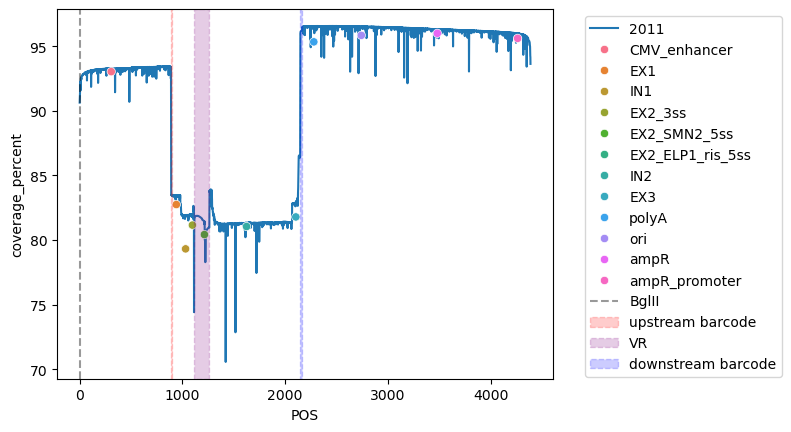

In [20]:
sns.lineplot(x='POS', y='coverage_percent', data=depth_long[depth_long['barcode']=='2011'], zorder=1, hue='barcode')
sns.scatterplot(x='POS', y='coverage_percent', hue='region', data=match_reads)

plt.axvline(x=1059-1059, color='k', linestyle='--', alpha=0.4, label='BglII')
plt.axvspan(xmax=1948-1059, xmin=1953-1059, color='red', linestyle='--', alpha=0.2, label='upstream barcode')
plt.axvspan(xmax=2173-1059, xmin=2322-1059, color='purple', linestyle='--', alpha=0.2, label='VR')
plt.axvspan(xmax=3206-1059, xmin=3225-1059, color='blue', linestyle='--', alpha=0.2, label='downstream barcode')
# plt.yscale('log')  
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [23]:
positions_2015 = pd.Series({
    "CMV_enhancer":1367,
    "EX1":2000,
    "IN1":2090,
    "EX2_3ss":2156,
    "EX2_SMN2_5ss":np.nan,
    "EX2_ELP1_ris_5ss":2273,
    "IN2":2683,
    'EX3':3162,
    "polyA":3337,
    "ori":3799,
    "ampR":153,
    "ampR_promoter":934,
    
})
rotated_positions_2015 = positions_2015-1059
rotated_positions_2015.loc[rotated_positions_2015<0] = 4385+rotated_positions_2015.loc[rotated_positions_2015<0]
positions_2015 = rotated_positions_2015

match_reads = match_df.drop(columns=['query_name']).groupby('file_name').sum()
match_reads = match_reads.loc[['m84223_251126_143521_s2.hifi_reads.bc2015.bam']].T/total_reads_2015*100
match_reads['POS'] = positions_2015

match_reads = match_reads.reset_index().rename(columns={'index':'region','m84223_251126_143521_s2.hifi_reads.bc2015.bam':'coverage_percent'})

match_reads

file_name,region,coverage_percent,POS
0,CMV_enhancer,90.826909,308.0
1,EX1,82.969445,941.0
2,IN1,79.618214,1031.0
3,EX2_3ss,81.413214,1097.0
4,EX2_SMN2_5ss,0.080331,NaN
5,EX2_ELP1_ris_5ss,81.084020,1214.0
6,IN2,71.395644,1624.0
7,EX3,72.282776,2103.0
8,polyA,93.048163,2278.0
9,ori,93.584377,2740.0


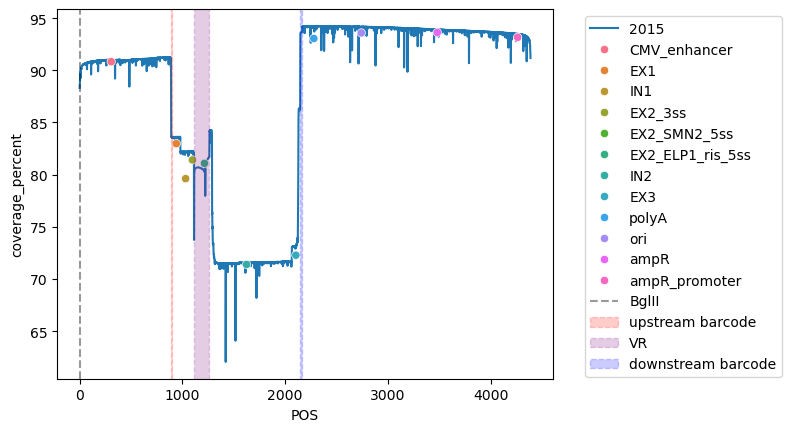

In [24]:

sns.lineplot(x='POS', y='coverage_percent', data=depth_long[depth_long['barcode']=='2015'], zorder=1, hue='barcode')
sns.scatterplot(x='POS', y='coverage_percent', hue='region', data=match_reads)


plt.axvline(x=1059-1059, color='k', linestyle='--', alpha=0.4, label='BglII')
plt.axvspan(xmax=1948-1059, xmin=1953-1059, color='red', linestyle='--', alpha=0.2, label='upstream barcode')
plt.axvspan(xmax=2173-1059, xmin=2322-1059, color='purple', linestyle='--', alpha=0.2, label='VR')
plt.axvspan(xmax=3206-1059, xmin=3225-1059, color='blue', linestyle='--', alpha=0.2, label='downstream barcode')
# plt.yscale('log')  
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()